# Feature Selection & Extraction
### Jimmy Azar

Visualizing datasets in 2 or 3 dimensions is quite convenient. However, when the number of features is in the order of tens, hundreds, or thousands, feature reduction becomes an essential tool. Visualization is one motivation for feature reduction. Another reason for reducing dimensionality is to improve statistical estimates, such as when estimating the covariance matrix of a dataset. Sometimes a large amount of data is required to estimate even simple parameters in 3 dimensional spaces. With higher dimensions, the number of samples required grows exponentially. Therefore, it would be far easier to remove dimensions rather than add samples, especially that the latter may not be possible. Feature reduction is crucial for a large portion of classification tasks as well as regression problems. We'll explore two general approaches to dimensionality reduction: *feature selection* and *feature extraction*.

## Feature Selection

In feature selection, we simply select a subset of features from the available ones and drop the others. In order to do this, we require a criterion function to assess a given feature subset and a method to choose subsets, that is, we require a search algorithm. Search algorithms include 'the best individual *d* features', forward selection, backward selection, plus-l-take-away-r selection, and branch & bound. 

We'll explore backward selecion. We can choose the desired number of features through the parameter 'n_features_to_select'. We'll use the support vector classifier to obtain classification rates of feature subsets as our criterion.

In [1]:
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.feature_selection import RFE
from sklearn.svm import SVC

iris = datasets.load_iris()
meas = iris.data        
y = iris.target         
X = np.random.multivariate_normal(mean=[0]*10, cov=np.diag([1]*10), size=150)
X = pd.DataFrame(X, columns=[f'V{i}' for i in range(10)])

X[['V0','V2','V4','V6']] = meas

svc = SVC(kernel="linear", C=1)
rfe = RFE(estimator=svc, n_features_to_select=4, step=1)
rfe.fit(X, y)
rfe.support_.nonzero() 

(array([0, 2, 4, 6]),)

## Principal Component Analysis

Principal component analysis is a linear, unsupervised feature extraction method. PCA is often applied when working with signals such as sound, speech, images, etc.

We load the data from the file 'sonar.txt'. The dataset consists of echo signals with 60 features. We apply PCA to the data and plot the ratio of retained variance to total variance. This should be in the range $[0,1]$. We also obtain the object coordinates in the transformed feature space.

Finally, we repeat the previous the procedure, however, this time we normalize the data properly prior to applying PCA. Notably, PCA is sensitive to the scaling of features. Therefore, we should normalize the data prior to applying PCA.

Usually, we select a number of components that retain around 90% of the total variance.

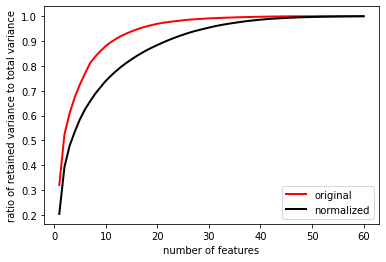

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

path_to_file = '../data/sonar.txt'
a = pd.read_csv(path_to_file,sep=' ')

pca = PCA() 
pca.fit(a)
rv = pca.explained_variance_.cumsum()/pca.explained_variance_.sum()

a_scaled = StandardScaler().fit_transform(a)  
pca = PCA().fit(a_scaled)
rv_scaled = pca.explained_variance_.cumsum()/pca.explained_variance_.sum()

plt.plot(np.arange(1,60+1),rv,linewidth=2,color='red')
plt.plot(np.arange(1,60+1),rv_scaled,linewidth=2,color='black')
plt.xlabel('number of features')
plt.ylabel('ratio of retained variance to total variance')
plt.legend(['original','normalized'])
plt.show()

## Fisher Mapping

The Fisher mapping is a form of supervised, linear feature extraction.

We load the iris dataset which has four features and apply the fisher mapping to obtain two features.

In [3]:
from sklearn import datasets
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

iris = datasets.load_iris()
X = iris.data       
y = iris.target     

lda = LDA()
X_new = lda.fit_transform(X,y)
lda.fit(X,y).scalings_; # these are the coefficients

Derive the mapped data points in the new feature space, and plot the objects in the resulting two-dimensional (mapped) feature space while assigning each class a different color.

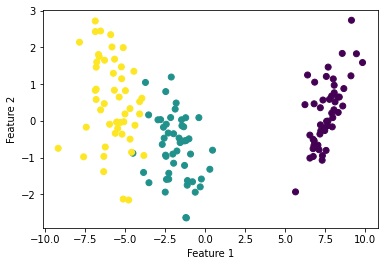

In [4]:
plt.scatter(X_new[:,0],X_new[:,1],c=y) 
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

## Nonlinear Feature Extraction & Embedding

We'll investigate nonlinear multi-dimensional scaling as a feature extraction method.

### Multi-dimensional Scaling

We explore the effect of nonlinear multi-dimensional scaling visually in comparison to PCA, which is a linear mapping.

Let's load the data from the file 'circles.txt' which contains 3 features. We generate a 3D scatter plot. Then, we apply PCA using the whole dataset and create a 2D scatter plot using the first two principal components.

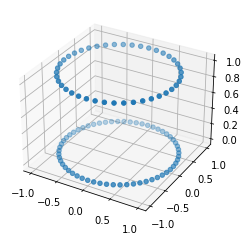

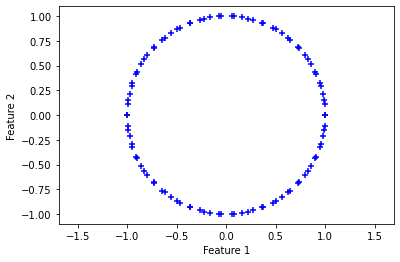

In [5]:
path_to_file = '../data/circles.txt'
a = pd.read_csv(path_to_file,sep=' ')

# 3d plot
ax = plt.axes(projection='3d')
ax.scatter(a['f1'],a['f2'],a['f3'])
plt.show()

# pca
X_pca = PCA(n_components=2).fit_transform(a) 

plt.scatter(X_pca[:,0],X_pca[:,1],color='blue',marker='+')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.axis('equal')
plt.show()

Using the same dataset, we now apply multi-dimensional scaling. We'll use 'n_components=2' as the desired number of dimensions. We create a 2D scatter plot of the result.

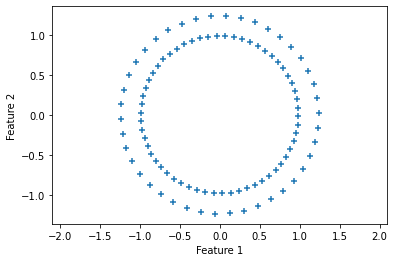

In [6]:
from sklearn.manifold import MDS

mds = MDS(n_components=2, max_iter=3000, dissimilarity="euclidean")
pos = mds.fit_transform(a)  

plt.scatter(pos[:,0],pos[:,1],marker='+') 
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.axis('equal')
plt.show()

We load the data from the file 'lines.txt' which contains 5 features. Then, we create a 3D scatter plot using the first 3 features. We apply PCA on the entire 5D-dataset and create a 2D scatter plot for the first two principal components.

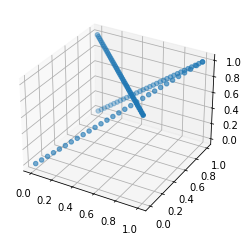

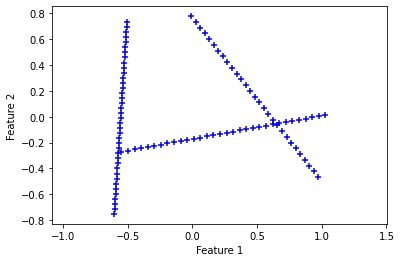

In [7]:
path_to_file = '../data/lines.txt'
a = pd.read_csv(path_to_file,sep=' ')

# 3d plot
ax = plt.axes(projection='3d')
ax.scatter(a['f1'],a['f2'],a['f3'])
plt.show()

# pca
X_pca = PCA(n_components=2).fit_transform(a) 

plt.scatter(X_pca[:,0],X_pca[:,1],color='blue',marker='+')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.axis('equal')
plt.show()


Next, we repeat the procedure using multidimensional scaling.

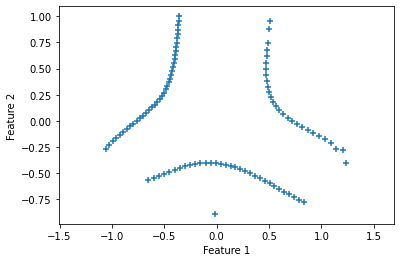

In [8]:
mds = MDS(n_components=2, max_iter=3000, dissimilarity="euclidean")
pos = mds.fit_transform(a)  

plt.figure()
plt.scatter(pos[:,0],pos[:,1],marker='+') 
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.axis('equal')
plt.show()

Multi-dimensional scaling can help highlight structure in the data that otherwise linear mappings may not be able to show. However, the structure may appear distorted in lower dimensions.

## Genetic Algorithms

We'll explore genetic algorithms which we'll apply on a known error function.

Suppose we are given an error function, and we want to find its global minimum. Suppose the function is Rastrigin's function defined as:

$$e(x_1,x_2) = 20 + x_1^2 + x_2^2 - 10 (cos(2\pi x_1) + cos(2 \pi x_2)), \hspace{1em} x_1,x_2 \in R$$

It's known that the global minimum lies at $(x_1, x_2) = (0,0)$. However, we assume that we don't know this, and we'll try to look for the global minimum.

We create a function named **Rastrigin(x)** which returns the error as defined above. The parameter **x** is either a list or array whose first element is $x_1$ and second element $x_2$. Then, we plot the error function for $x_1, x_2 \in [-3,3]$.

Finally, we show the error values in a heatmap.

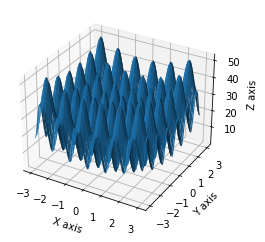

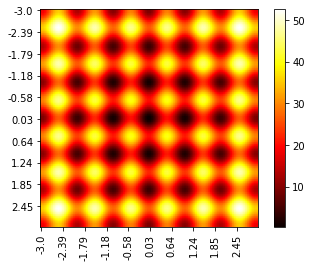

In [9]:
def Rastrigin(x):
    err = 20 + x[0]**2 + x[1]**2 - 10*(np.cos(2*np.pi*x[0]) + np.cos(2*np.pi*x[1]))
    return err

x1 = np.linspace(-3,3,100)
x2 = np.linspace(-3,3,100)

e = np.array([Rastrigin([i,j]) for i in x1 for j in x2]).reshape(len(x1),len(x2))
e = pd.DataFrame(e, index=x1, columns=x2)

# surface plot
import matplotlib.pyplot as plt

ax = plt.axes(projection="3d")
x, y = np.meshgrid(x1, x2)
ax.plot_surface(x,y,e)
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Z axis')
plt.show()

# heatmap/contours
ticks_loc = np.arange(0,len(e.columns),10)
plt.xticks(ticks=ticks_loc, labels=x1.round(2)[ticks_loc], rotation=90)
plt.yticks(ticks=ticks_loc, labels=x2.round(2)[ticks_loc])
plt.imshow(e,cmap='hot') 
plt.colorbar()
plt.show()

The error function contains local mimina all around the global minimum at (0,0). This makes it impossible for gradient descent algorithms to converge to the global minimum unless the initial starting point happens to fall very close to the global minimum, which is an unrealistic assumption. Instead, we'll use a genetic algorithm in an attempt to find the global minimum efficiently.

The first argument is a call to the error function. We also specify the variable boundaries, which in this case are $[-3,3]$. We can set the number of individuals in the population using `population_size`. We can set the ratio of elite individuals passing on to the next generation without change using `elit_ratio`. Finally, we can set the fraction of offspring that is generated by crossover using `crossover_probability`.

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip available: 22.3.1 -> 24.0
[notice] To update, run: pip3 install --upgrade pip
 The best solution found:                                                                           
 [-3.25140499e-05  3.36875746e-04]

 Objective function:
 2.2724303768484333e-05


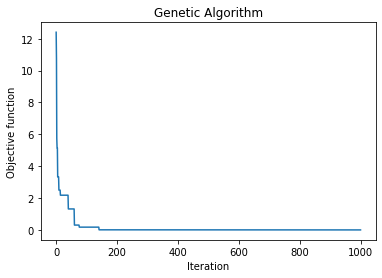

In [10]:
import sys
!{sys.executable} -m pip install geneticalgorithm

from geneticalgorithm import geneticalgorithm as ga  

varbound = np.array([[-3,3]]*2)
algorithm_param = {'max_num_iteration':1000,
                   'population_size':20,
                   'mutation_probability':0.2,
                   'elit_ratio':2/100,
                   'crossover_probability':0.8,
                   'parents_portion': 0.3,
                   'crossover_type':'uniform',
                   'max_iteration_without_improv':None}

model = ga(function=Rastrigin, dimension=2, variable_type='real', 
           variable_boundaries=varbound, algorithm_parameters=algorithm_param)
model.run()